*Companion notebook for the handout* **Cards to rows: the Oscars, one step at a time** *(Week 6 · Documents module · Textbook Chapter 6, Strategy 6), INFO 4617 Web Data Science, University of Colorado Boulder.*

*Generated from `oscars-cards-to-rows.qmd` by `make` in `handouts/`: edit the `.qmd`, not this notebook. The code cells are not run yet. Run them in order and compare what you get with the outputs in `oscars-cards-to-rows.pdf`.*

## What you will build

The page for the 98th Academy Awards
(<https://www.oscars.org/oscars/ceremonies/2026>) lists 24 award
categories. It has no `<table>`. Each category is a *card*: a name, then
one block for each honoree, first the winner and then the nominees. Each
honoree block names a person or group and a film (Figure 1). This handout
builds the loop from Wednesday's slide one piece at a time and turns the
cards into a DataFrame with one row per honoree:

| category | honoree_type | entity | film |
|:--|:--|:--|:--|
| Actor in a Leading Role | Winner | Michael B. Jordan | Sinners |
| Actor in a Leading Role | Nominees | Timothée Chalamet | Marty Supreme |

*… 125 rows in all, from 24 cards*

Each step adds one thing to the step before it. Run each code cell in
order, and compare what you get with the output in the PDF handout before
you go to the next step. The numbers ① to ⑦ mark the same seven parts of
a card in every figure and step.

![Screenshot of the Actor in a Leading Role card on oscars.org: the gold heading, then WINNER, MICHAEL B. JORDAN, Sinners, then NOMINEES and four more names with their films, then the next card, Actor in a Supporting Role. Numbered markers label the area around all the cards, one card, its name, one honoree, and the honoree's type, name, and film.](attachment:oscars_card_annotated.png)

**Figure 1.** One card as the browser shows it, September 24, 2026. The
numbers match Figure 2 in Step 3.
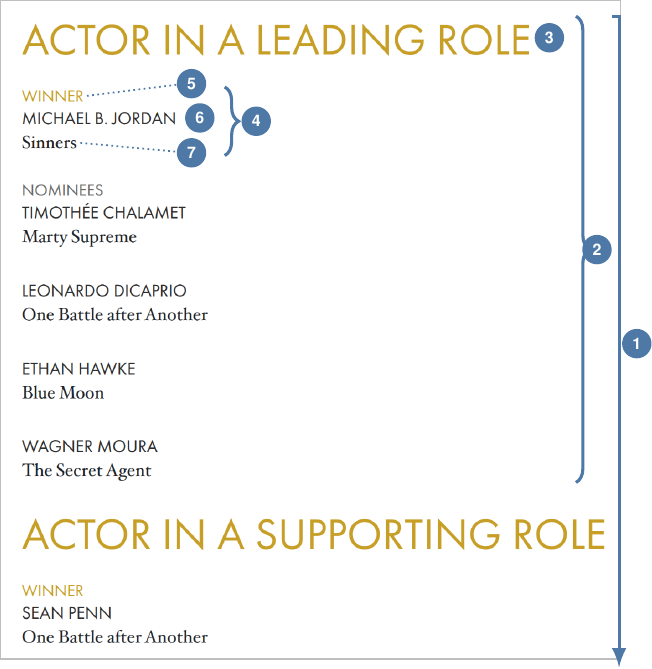

## Step 1 — Ask for the page, and say who you are

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.oscars.org/oscars/ceremonies/2026"
headers = {"User-Agent": "Web Data Science/v1 brian.keegan@colorado.edu"}
response = requests.get(url, headers=headers)
response.status_code

The `User-Agent` header tells the server who is asking: this course and a
contact address. Without it, oscars.org answers `403` (Forbidden). `200`
means that the server sent the page. In your own projects, put your own
name and address in the header.

## Step 2 — Parse the HTML

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
soup.title.get_text()

`soup` holds the page as a tree of tags that you can search. The title
tells you that you have the ceremony page, not an error page.

## Step 3 — Find one card in DevTools

Open the page in Chrome, right-click the name MICHAEL B. JORDAN, and
select **Inspect**. The Elements panel opens with the `<div>` for that name
selected (Figure 2). Each indented line sits inside the nearest
less-indented line above it: read up to find the containers around the
name, and down to find the parts next to it. Click a triangle to open a
line; Figure 2 has the film's `<div class="field">` open.

The `class` attribute on each line holds several class names, separated by
spaces; the line at ⑤ has three: `field`,
`field--name-field-honoree-type`, and `winner`. oscars.org is built with
Drupal, a content management system that makes most of these names from
the site's own field names: `field--name-` plus a field name, and
`paragraph--type--` plus a type of block. These names tell you what a div
holds; names such as `field` and `field__item` tell you only that the div
is a box.

![Screenshot of the Chrome DevTools Elements panel for the Actor in a Leading Role card. Nested div tags, each with a long class attribute: the categories area, one category card with the name Actor in a Leading Role, the honorees list, and the first honoree with Winner, Michael B. Jordan (selected), and Sinners. Four more honorees are collapsed below. Numbered markers 1 to 7 point to the seven class names that the code uses.](attachment:oscars_devtools_annotated.png)

**What each part holds**

- ① the area that holds all 24 cards
- ② one card (a category)
- ③ the card's name
- ④ one honoree, a winner or a nominee
- ⑤ `Winner` or `Nominees`
- ⑥ the person or group (the *entity*)
- ⑦ the film

**Figure 2.** Chrome DevTools, Elements panel, after **Inspect** on
MICHAEL B. JORDAN. September 24, 2026.
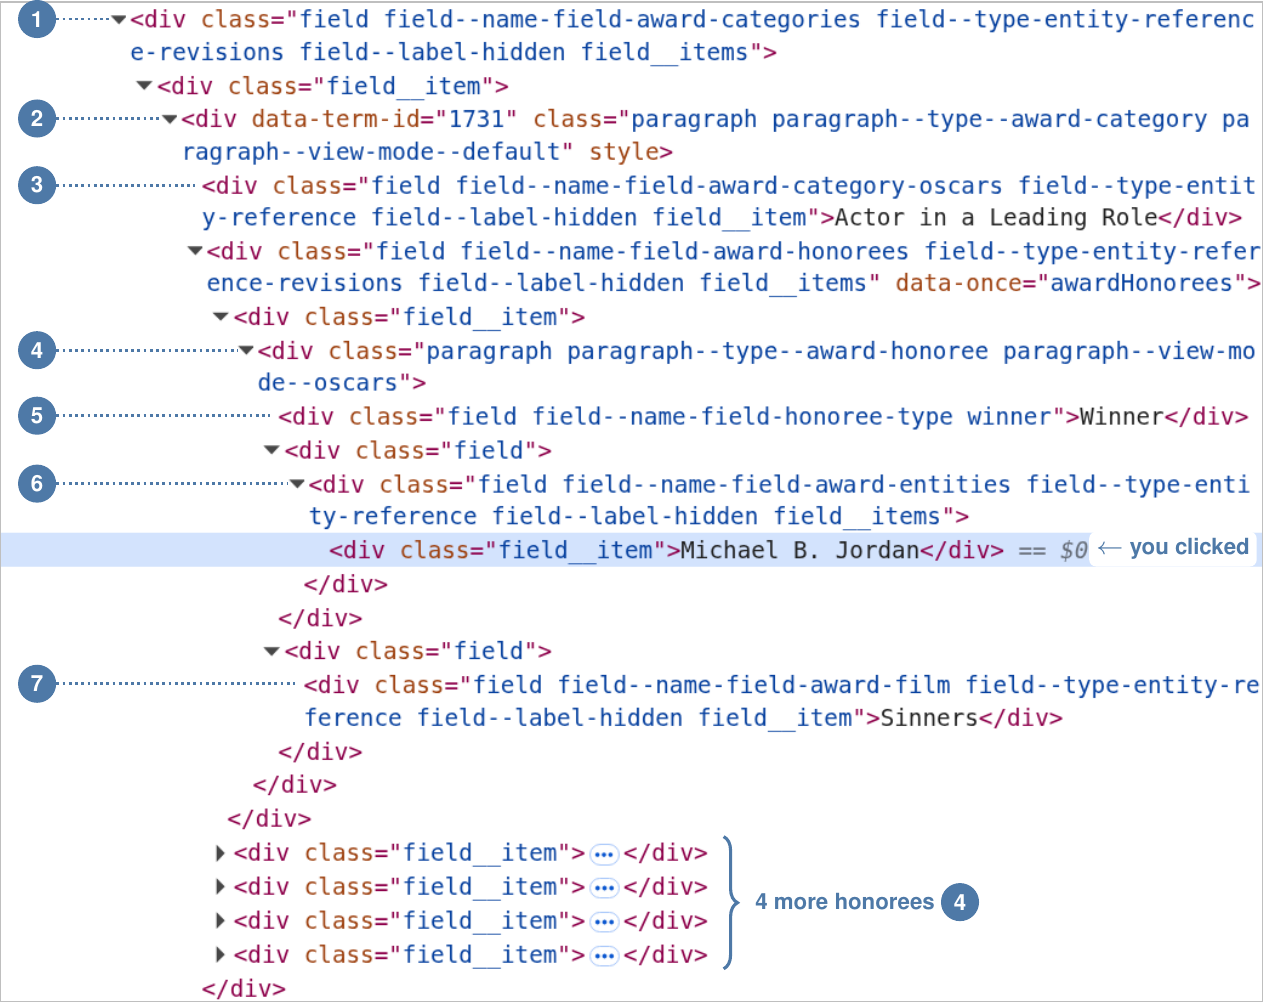

## Step 4 — Match one class name, then count the matches

In [ ]:
name_tag = soup.find("div", class_="field--name-field-award-category-oscars")
name_tag["class"]

BeautifulSoup keeps the `class` attribute as a list of names.
`class_="..."` matches a tag when your name is any one item in that list,
so you give only the one name that you need. (The underscore is necessary
because `class` is a reserved word in Python.) Now count what each name
matches on the whole page. The last item is the whole attribute from the
line at ⑤, copied from DevTools:

In [ ]:
for name in ["field", "field__item", "paragraph",
             "field--name-field-award-categories", "paragraph--type--award-category",
             "field--name-field-award-category-oscars", "paragraph--type--award-honoree",
             "field--name-field-honoree-type", "field--name-field-award-entities",
             "field--name-field-award-film",
             "field field--name-field-honoree-type winner"]:
    print(len(soup.find_all("div", class_=name)), name)

The general names match hundreds of divs across the page; the specific
names match only what you want. Check each count against the page: it
shows 24 category headings, so 24 cards ② is correct, and 125 honorees ④
with 125 of each field ⑤ ⑥ ⑦ means one of each per honoree. The whole
attribute finds only the 25 winners, because a string with spaces must
match the attribute exactly, names and order. Select the one name that
describes the content, then check its count.

## Step 5 — Go to the area ①, then collect the cards ②

In [ ]:
area = soup.find("div", class_="field--name-field-award-categories")
categories = area.find_all("div", class_="paragraph--type--award-category")
len(categories)

`find` returns the first match: one tag. `find_all` returns a list of all
the matches. You call `find_all` on `area`, not on `soup`, so it searches
only inside the awards area. `categories` is a list of the 24 cards, in
the order of the page.

## Step 6 — Take one card and read its name ③

In [ ]:
cat = categories[0]
name_tag = cat.find(class_="field--name-field-award-category-oscars")
name_tag.get_text(strip=True)

Build the steps for one card before you build them for 24.
`cat.find(...)` searches only inside this card. This `find` has no
`"div"`, so it matches any tag with the class; every field on this page is
a div, so both forms work. `get_text(strip=True)` gives the text inside the
tag, without the spaces and line breaks around it.

## Step 7 — Collect the honorees ④ in that one card

In [ ]:
honorees = cat.find_all("div", class_="paragraph--type--award-honoree")
len(honorees)

In Step 4, this class name matched 125 divs on the whole page. Searched
from `cat`, it matches the 5 in this card. Where you start a search
decides what you get back. `find_all` also looks at every level below
`cat`, so you do not step through the two wrapper divs between the card
and its honorees (`field--name-field-award-honorees` and `field__item` in
Figure 2).

## Step 8 — Extract the three fields ⑤ ⑥ ⑦ from one honoree

In [ ]:
h = honorees[0]
type_tag = h.find(class_="field--name-field-honoree-type")
entity_tag = h.find(class_="field--name-field-award-entities")
film_tag = h.find(class_="field--name-field-award-film")
print(type_tag.get_text(strip=True))
print(entity_tag.get_text(strip=True))
print(film_tag.get_text(strip=True))

Each `find` starts from `h`, so it finds only the fields of this honoree.
To see what `strip=True` removes, look at the raw text:

In [ ]:
entity_tag.text

The line breaks come from the HTML around the inner `field__item` div. The
type is also a class name (`winner` or `nominee`), but the text is what you
want in the table.

## Step 9 — Make one row for each honoree in the card

In [ ]:
category_name = name_tag.get_text(strip=True)
rows = []
for h in honorees:
    rows.append({
        "category": category_name,
        "honoree_type": h.find(class_="field--name-field-honoree-type").get_text(strip=True),
        "entity": h.find(class_="field--name-field-award-entities").get_text(strip=True),
        "film": h.find(class_="field--name-field-award-film").get_text(strip=True),
    })
rows[1]

The three `find` calls from Step 8 go inside the loop, and their text goes
into a dictionary: one dictionary per row, keys as column names (`rows[1]`
is the second of 5). `category_name`, from Step 6, puts the card's name in
each row. The page shows NOMINEES once, but the HTML has the label in
every nominee block: a script hides the repeats in the browser
(`style="display: none;"` in DevTools), and `requests` does not run
scripts, so every row gets its label.

## Step 10 — Put the card loop inside a loop over all 24 cards

In [ ]:
rows = []
for cat in categories:                                                      # Step 5
    name_tag = cat.find(class_="field--name-field-award-category-oscars")   # Step 6
    if name_tag is None:                                                    # guard
        continue
    category_name = name_tag.get_text(strip=True)                           # Step 6
    for h in cat.find_all("div", class_="paragraph--type--award-honoree"):  # Step 7
        type_tag = h.find(class_="field--name-field-honoree-type")          # Step 8
        entity_tag = h.find(class_="field--name-field-award-entities")      # Step 8
        film_tag = h.find(class_="field--name-field-award-film")            # Step 8
        rows.append({                                                       # Step 9
            "category": category_name,
            "honoree_type": type_tag.get_text(strip=True) if type_tag else None,
            "entity": entity_tag.get_text(strip=True) if entity_tag else None,
            "film": film_tag.get_text(strip=True) if film_tag else None,
        })
len(rows)

Two things are new. The outer loop `for cat in categories:` runs Steps 6
to 9 once per card, and `rows = []` moves above it so all 24 cards add to
one list. And guards: `find` returns `None` when nothing matches, and
`.get_text()` on `None` raises an `AttributeError` that stops the loop.
`if name_tag is None: continue` skips a card with no name;
`... if type_tag else None` records a missing field as `None`. No guard
fires on the 2026 page; the guards keep the loop running if one card is
shaped differently.

## Step 11 — Make the DataFrame, then check it against the page

In [ ]:
df = pd.DataFrame(rows)
df.shape

In [ ]:
df.head()

In [ ]:
df["honoree_type"].value_counts()

25 winners for 24 categories looks like a bug in the loop. Look at the
winners of one category:

In [ ]:
df[(df["category"] == "Live Action Short Film") & (df["honoree_type"] == "Winner")]

The category ended in a tie (the first Oscars tie since 2013), so the
table is correct: check a surprising number against the page before you
change your code. Check what each column holds, too. You named the
columns, but the site decides what goes in each field: for International
Feature Film, `entity` is the film and `film` is the country (*Sentimental
Value*, Norway); for Music (Original Song), `film` is the song title.

> **The whole path.**
>
> `soup` → area ① → each card ② → its name ③ and honorees ④ → each
> honoree's type ⑤, entity ⑥, and film ⑦ → one dictionary per row →
> `pd.DataFrame(rows)`. If your counts differ, the page has changed: inspect
> a card again (Figure 2).